# Idea:

MARL with PettingZoo: `simple_tag_v3`.

Want to try `MATD3`.

In [17]:
!pip install agilerl pettingzoo mpe2

### Imports

In [1]:
import os
import torch
import numpy as np
from mpe2 import simple_tag_v3
from agilerl.algorithms.matd3 import MATD3
from agilerl.components.multi_agent_replay_buffer import MultiAgentReplayBuffer
from agilerl.utils.utils import make_multi_agent_vect_envs

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [4]:
from google.colab import drive
drive.mount('/content/drive')
dir_path = '/content/drive/MyDrive/Colab Notebooks'

Mounted at /content/drive


### Env

In [5]:
# https://docs.agilerl.com/en/latest/multi_agent_training/index.html#vectorised-environments
# Init env (continuous_actions=True for MATD3)
# function that returns a single un-initialized environment
def make_env():
    """Return single un-initialized environment."""
    return simple_tag_v3.parallel_env(
        num_good=1,
        num_adversaries=3,
        num_obstacles=2,
        max_cycles=100,
        continuous_actions=True
    )

# Number of envs to be run in parallel
num_envs = 8

# Vectorized environment
env = make_multi_agent_vect_envs(make_env, num_envs=num_envs)

In [6]:
# Agents
agent_ids = env.agents

# Spaces
observation_spaces = [env.single_observation_space(agent) for agent in agent_ids]
action_spaces = [env.single_action_space(agent) for agent in agent_ids]

In [7]:
# These are [lower bound, upper bound, shape and type]
observation_spaces

[Box(-inf, inf, (16,), float32),
 Box(-inf, inf, (16,), float32),
 Box(-inf, inf, (16,), float32),
 Box(-inf, inf, (14,), float32)]

In [8]:
action_spaces

[Box(0.0, 1.0, (5,), float32),
 Box(0.0, 1.0, (5,), float32),
 Box(0.0, 1.0, (5,), float32),
 Box(0.0, 1.0, (5,), float32)]

### MATD3

In [9]:
# NN config (https://docs.agilerl.com/en/latest/api/algorithms/matd3.html#matd3)
NET_CONFIG = {
    "encoder_config": {
        "hidden_size": [64, 64]  # "body"
    },
    "head_config": {
        "hidden_size": [32]      # "final layer"
    }
}

# "Agent"
agent = MATD3(
    observation_spaces=observation_spaces,
    action_spaces=action_spaces,
    agent_ids=agent_ids,
    vect_noise_dim=num_envs,
    net_config=NET_CONFIG,
    batch_size=512,
    lr_actor=0.001,
    lr_critic=0.001,
    device=device
)

### Buffer

In [10]:
# Multi agent replay buffer
field_names = ["state", "action", "reward", "next_state", "done"]
memory = MultiAgentReplayBuffer(
    memory_size=1000000,
    field_names=field_names,
    agent_ids=agent_ids,
    device=device
)

### Training

#### First

In [10]:
# Model saving
run_name = 'first'
path_chkpt = os.path.join(dir_path, f"matd3_simple_tag_{run_name}.pt")

# Eps
episodes = 10000
max_steps = 100
learn_freq = 10

# History for graphing
predator_history, prey_history = [], []

for ep in range(episodes):
    # Reset
    obs, info = env.reset()

    # Trackers
    ep_predator_reward, ep_prey_reward = np.zeros(num_envs), np.zeros(num_envs)

    for step in range(max_steps):
        # Actions for all agents
        action, raw_action = agent.get_action(obs) # These are shape [1, 5]

        # Squeeze (but they're dicts) [not needed since we vectorised]
        #env_action = {agent: act[0] for agent, act in action.items()}
        #env_raw_action = {agent: act[0] for agent, act in raw_action.items()}

        # Step forward
        next_obs, reward, termination, truncation, info = env.step(action) #env.step(env_action)

        # Check if agents are done
        done = {a: termination[a] | truncation[a] for a in agent_ids}

        # Save experience to centralized replay buffer (now vectorised)
        memory.save_to_memory(obs, raw_action, reward, next_obs, done, is_vectorised=True)

        # Update observation
        obs = next_obs

        # Accumulate rewards continuously during the episode
        for a in agent_ids:
            if 'adversary' in a:
                ep_predator_reward += reward[a]
            else:
                ep_prey_reward += reward[a]

        # Trigger learning if buffer is full enough and every 5 steps
        if len(memory) >= agent.batch_size and ((step+1) % learn_freq == 0):
            experiences = memory.sample(agent.batch_size)
            agent.learn(experiences)

        # Check if all games are done
        if all(d.all() for d in done.values()):
            break

    # Once the episode finishes, append the totals (avg) to the history
    predator_history.append(np.mean(ep_predator_reward))
    prey_history.append(np.mean(ep_prey_reward))

    # Print progress output
    if (ep + 1) % 50 == 0:
        print(f"Episode {ep + 1} | Predators: {np.mean(ep_predator_reward):.2f} | Prey: {np.mean(ep_prey_reward):.2f}")

env.close()

# Save the trained model
agent.save_checkpoint(path_chkpt)
print("Training complete and model saved.")

Episode 50 | Predators: 0.00 | Prey: -78.21
Episode 100 | Predators: 3.75 | Prey: -85.69
Episode 150 | Predators: 11.25 | Prey: -11.47
Episode 200 | Predators: 18.75 | Prey: -23.38
Episode 250 | Predators: 26.25 | Prey: -12.09
Episode 300 | Predators: 18.75 | Prey: -69.91
Episode 350 | Predators: 3.75 | Prey: -97.25
Episode 400 | Predators: 0.00 | Prey: -9.39
Episode 450 | Predators: 11.25 | Prey: -75.20
Episode 500 | Predators: 11.25 | Prey: -3.76
Episode 550 | Predators: 18.75 | Prey: -14.94
Episode 600 | Predators: 11.25 | Prey: -13.04
Episode 650 | Predators: 7.50 | Prey: -15.36
Episode 700 | Predators: 11.25 | Prey: -16.05
Episode 750 | Predators: 7.50 | Prey: -16.12
Episode 800 | Predators: 0.00 | Prey: -23.63
Episode 850 | Predators: 0.00 | Prey: -17.85
Episode 900 | Predators: 26.25 | Prey: -12.24
Episode 950 | Predators: 0.00 | Prey: -16.29
Episode 1000 | Predators: 0.00 | Prey: -15.49
Episode 1050 | Predators: 15.00 | Prey: -27.02
Episode 1100 | Predators: 11.25 | Prey: -10.3

In [14]:
import json

path_pred = os.path.join(dir_path, f"matd3_simple_tag_pred.json")
with open(path_pred, "w") as f:
    json.dump(predator_history, f)

path_prey = os.path.join(dir_path, f"matd3_simple_tag_prey.json")
with open(path_prey, "w") as f:
    json.dump(prey_history, f)

##### Plots

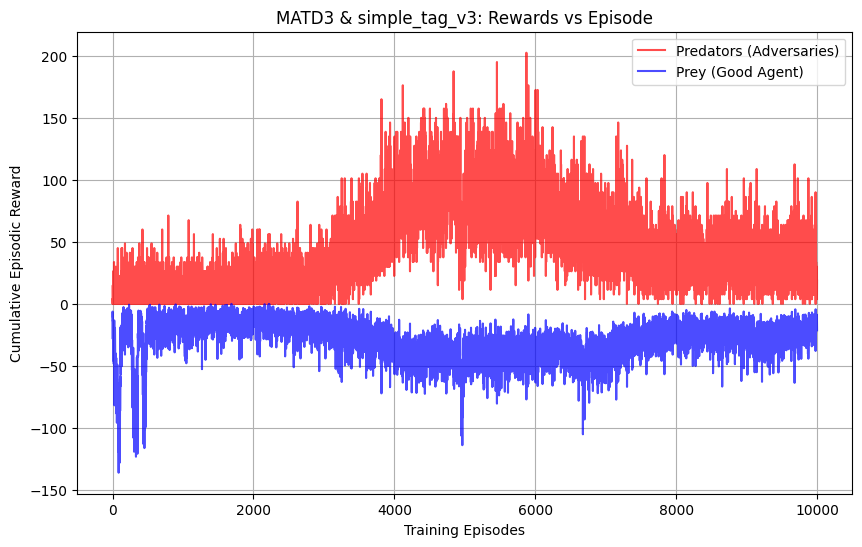

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(predator_history, label="Predators (Adversaries)", color="red", alpha=0.7)
plt.plot(prey_history, label="Prey (Good Agent)", color="blue", alpha=0.7)

plt.xlabel("Training Episodes")
plt.ylabel("Cumulative Episodic Reward")
plt.title("MATD3 & simple_tag_v3: Rewards vs Episode")
plt.legend()
plt.grid(True)
plt.show()

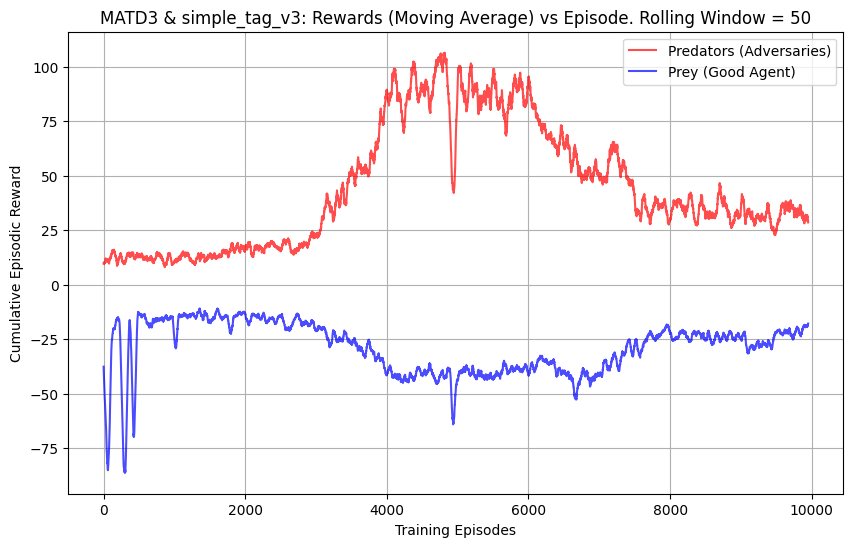

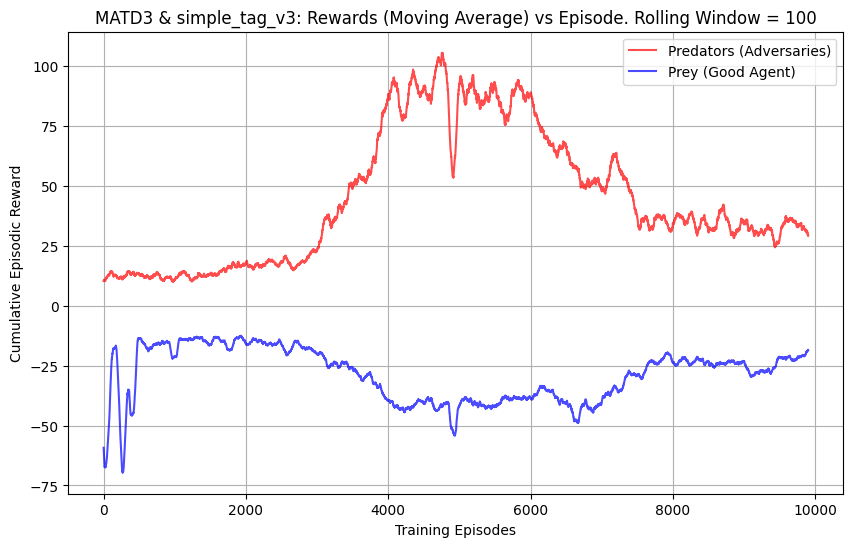

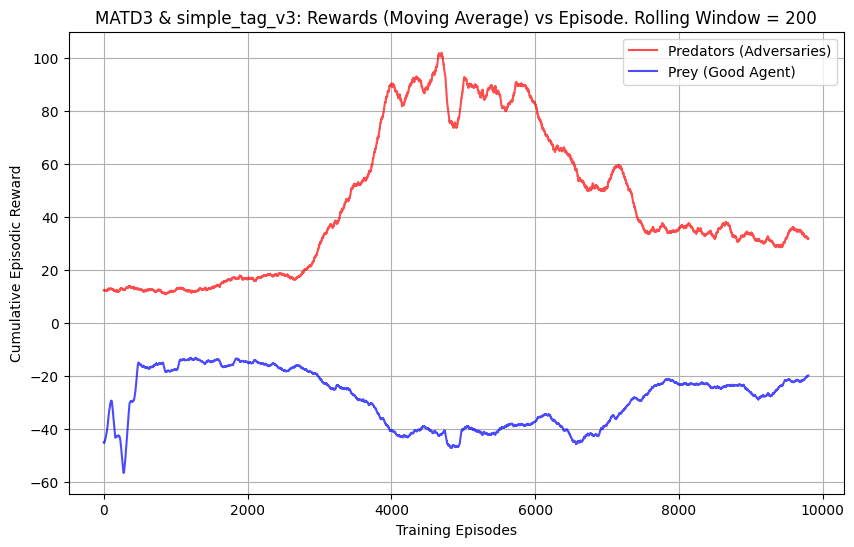

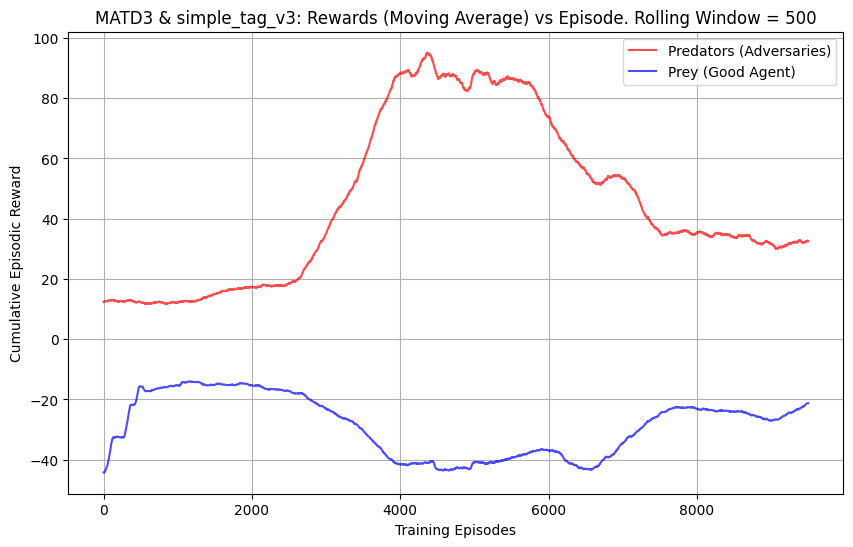

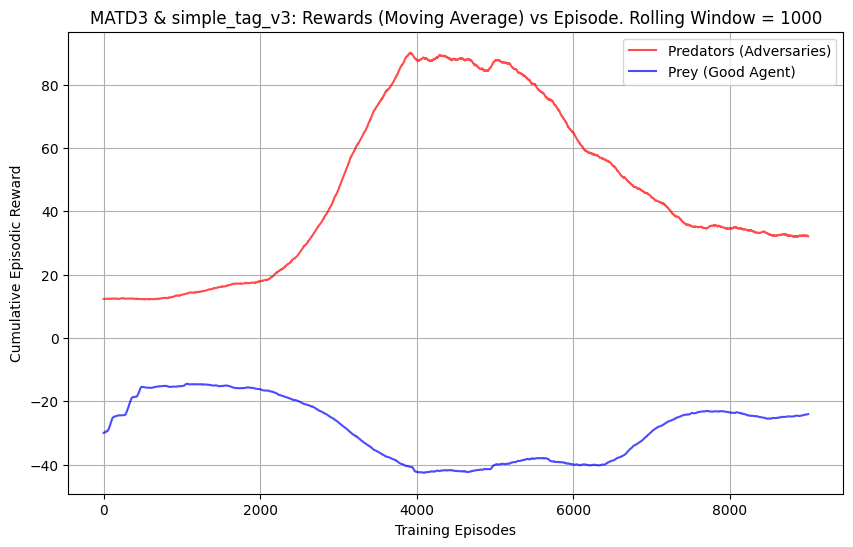

In [19]:
for roll_window in [50, 100, 200, 500, 1000]:
    predator_smoothed = np.convolve(predator_history, np.ones(roll_window)/roll_window, mode='valid')
    prey_smoothed = np.convolve(prey_history, np.ones(roll_window)/roll_window, mode='valid')

    plt.figure(figsize=(10, 6))
    plt.plot(predator_smoothed, label="Predators (Adversaries)", color="red", alpha=0.7)
    plt.plot(prey_smoothed, label="Prey (Good Agent)", color="blue", alpha=0.7)

    plt.xlabel("Training Episodes")
    plt.ylabel("Cumulative Episodic Reward")
    plt.title(f"MATD3 & simple_tag_v3: Rewards (Moving Average) vs Episode. Rolling Window = {roll_window}")
    plt.legend()
    plt.grid(True)
    plt.show()

##### Display

In [1]:
import imageio
from IPython.display import Image

GIF saved! Displaying below:


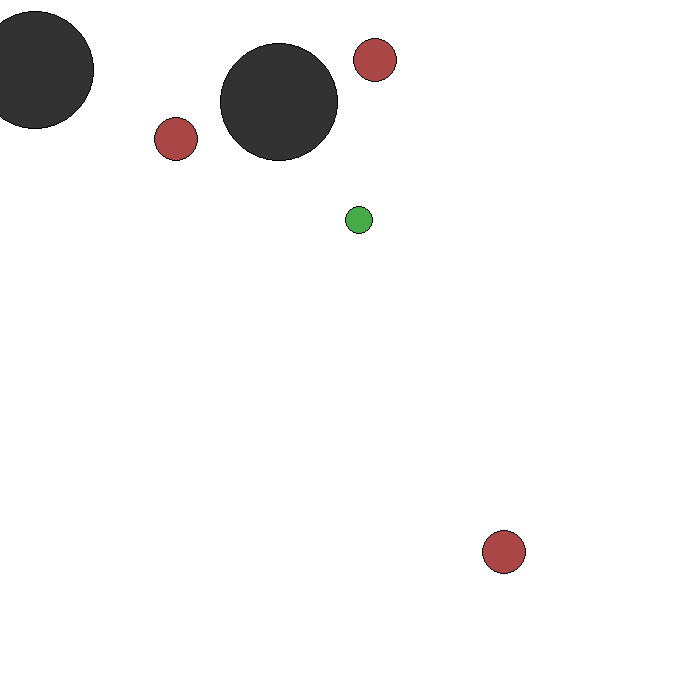

In [25]:
# Env with rendering
eval_env = simple_tag_v3.parallel_env(
    num_good=1,
    num_adversaries=3,
    num_obstacles=2,
    max_cycles=100,
    continuous_actions=True,
    render_mode="rgb_array",
    dynamic_rescaling=True,
)

obs, info = eval_env.reset()
frames = []

# Capture frames
while eval_env.agents:
    # Visual frame
    frames.append(eval_env.render())

    # Get actions
    action, _ = agent.get_action(obs)

    # Squeeze
    env_action = {a: act[0] for a, act in action.items()}

    # Step
    obs, reward, term, trunc, info = eval_env.step(env_action)

eval_env.close()

# Save gif
gif_path = os.path.join(dir_path, f"matd3_simple_tag_{run_name}.gif")
imageio.mimsave(gif_path, frames, fps=15)
print("GIF saved! Displaying below:")

# Display
Image(open(gif_path, 'rb').read())

#### Second


In [11]:
# Model saving
run_name = 'second'
path_chkpt = os.path.join(dir_path, f"matd3_simple_tag_{run_name}.pt")

# Eps
episodes = 5000
max_steps = 100
learn_freq = 10

# History for graphing
predator_history, prey_history = [], []

for ep in range(episodes):
    # Reset
    obs, info = env.reset()

    # Trackers
    ep_predator_reward, ep_prey_reward = np.zeros(num_envs), np.zeros(num_envs)

    for step in range(max_steps):
        # Actions for all agents
        action, raw_action = agent.get_action(obs) # These are shape [1, 5]

        # Squeeze (but they're dicts) [not needed since we vectorised]
        #env_action = {agent: act[0] for agent, act in action.items()}
        #env_raw_action = {agent: act[0] for agent, act in raw_action.items()}

        # Step forward
        next_obs, reward, termination, truncation, info = env.step(action) #env.step(env_action)

        # Check if agents are done
        done = {a: termination[a] | truncation[a] for a in agent_ids}

        # Save experience to centralized replay buffer (now vectorised)
        memory.save_to_memory(obs, raw_action, reward, next_obs, done, is_vectorised=True)

        # Update observation
        obs = next_obs

        # Accumulate rewards continuously during the episode
        for a in agent_ids:
            if 'adversary' in a:
                ep_predator_reward += reward[a]
            else:
                ep_prey_reward += reward[a]

        # Trigger learning if buffer is full enough and every 5 steps
        if len(memory) >= agent.batch_size and ((step+1) % learn_freq == 0):
            experiences = memory.sample(agent.batch_size)
            agent.learn(experiences)

        # Check if all games are done
        if all(d.all() for d in done.values()):
            break

    # Once the episode finishes, append the totals (avg) to the history
    predator_history.append(np.mean(ep_predator_reward))
    prey_history.append(np.mean(ep_prey_reward))

    # Print progress output
    if (ep + 1) % 50 == 0:
        print(f"Episode {ep + 1} | Predators: {np.mean(ep_predator_reward):.2f} | Prey: {np.mean(ep_prey_reward):.2f}")

env.close()

# Save the trained model
agent.save_checkpoint(path_chkpt)
print("Training complete and model saved.")

Episode 50 | Predators: 0.00 | Prey: -1676.30
Episode 100 | Predators: 15.00 | Prey: -1645.70
Episode 150 | Predators: 15.00 | Prey: -1341.67
Episode 200 | Predators: 11.25 | Prey: -412.08
Episode 250 | Predators: 18.75 | Prey: -644.96
Episode 300 | Predators: 18.75 | Prey: -490.11
Episode 350 | Predators: 7.50 | Prey: -217.70
Episode 400 | Predators: 26.25 | Prey: -181.71
Episode 450 | Predators: 22.50 | Prey: -403.89
Episode 500 | Predators: 30.00 | Prey: -272.92
Episode 550 | Predators: 3.75 | Prey: -234.46
Episode 600 | Predators: 52.50 | Prey: -49.52
Episode 650 | Predators: 18.75 | Prey: -74.76
Episode 700 | Predators: 22.50 | Prey: -59.37
Episode 750 | Predators: 45.00 | Prey: -199.06
Episode 800 | Predators: 33.75 | Prey: -221.21
Episode 850 | Predators: 37.50 | Prey: -176.70
Episode 900 | Predators: 26.25 | Prey: -162.75
Episode 950 | Predators: 82.50 | Prey: -114.48
Episode 1000 | Predators: 26.25 | Prey: -112.79
Episode 1050 | Predators: 0.00 | Prey: -149.43
Episode 1100 | P

In [12]:
import json

path_pred = os.path.join(dir_path, f"matd3_simple_tag_pred_{run_name}.json")
with open(path_pred, "w") as f:
    json.dump(predator_history, f)

path_prey = os.path.join(dir_path, f"matd3_simple_tag_prey_{run_name}.json")
with open(path_prey, "w") as f:
    json.dump(prey_history, f)

##### Plots

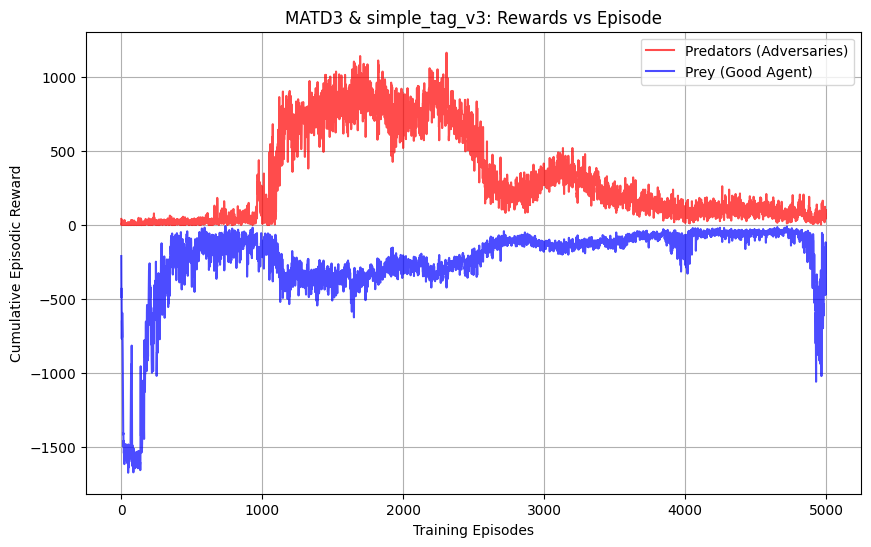

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(predator_history, label="Predators (Adversaries)", color="red", alpha=0.7)
plt.plot(prey_history, label="Prey (Good Agent)", color="blue", alpha=0.7)

plt.xlabel("Training Episodes")
plt.ylabel("Cumulative Episodic Reward")
plt.title("MATD3 & simple_tag_v3: Rewards vs Episode")
plt.legend()
plt.grid(True)
plt.show()

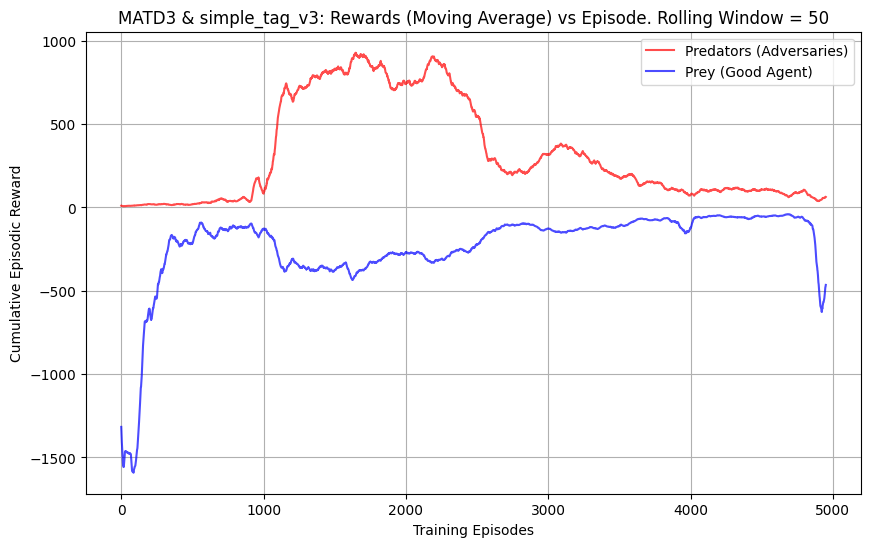

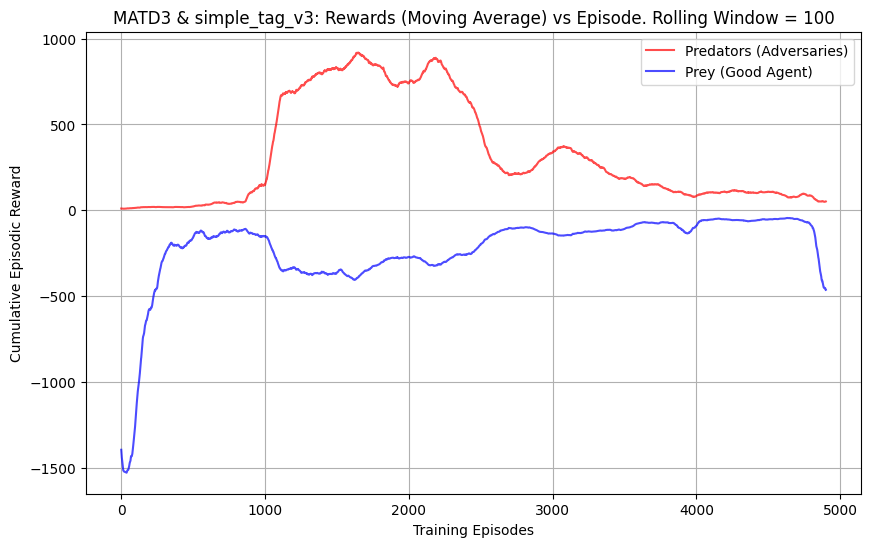

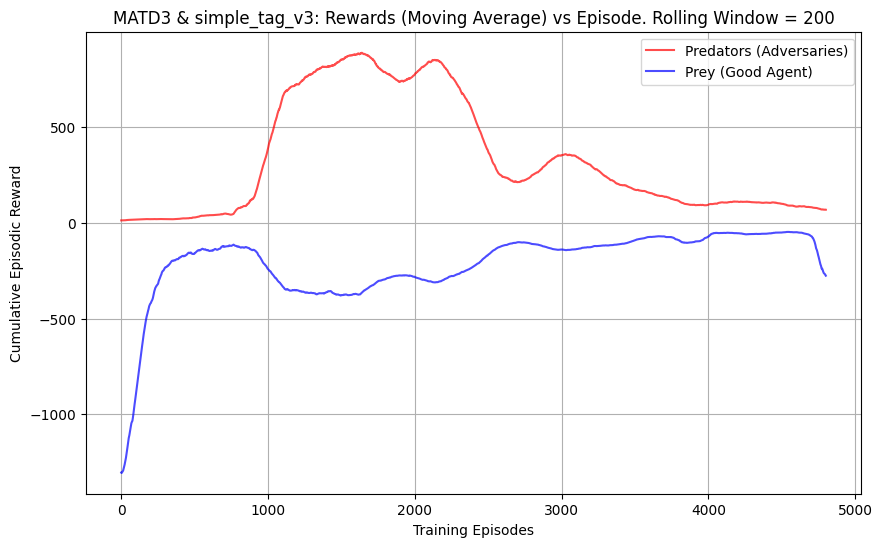

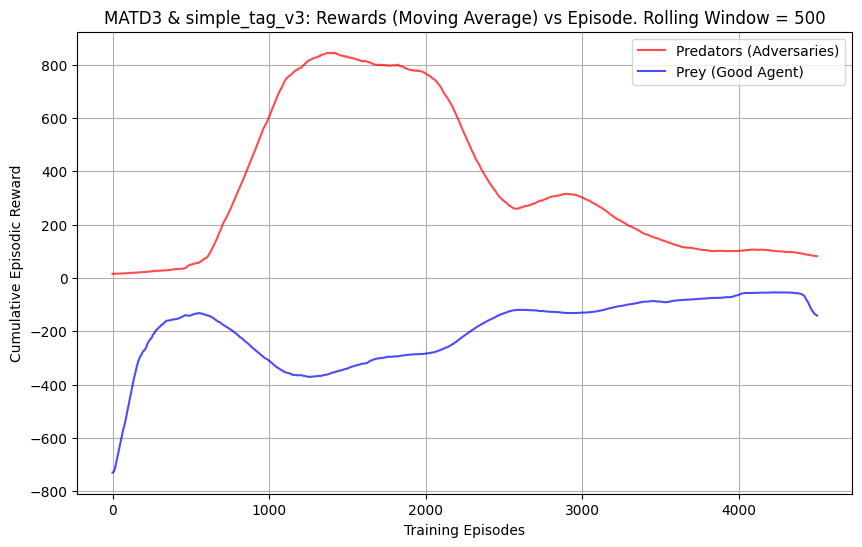

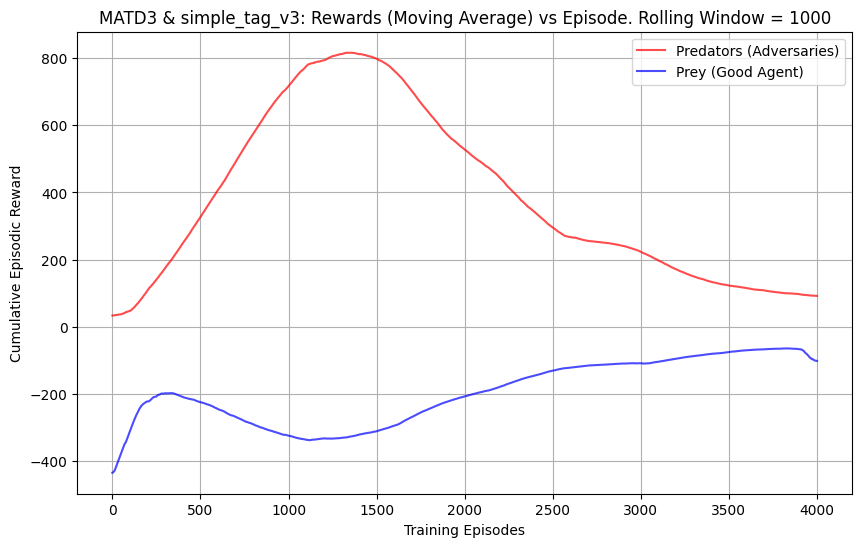

In [14]:
for roll_window in [50, 100, 200, 500, 1000]:
    predator_smoothed = np.convolve(predator_history, np.ones(roll_window)/roll_window, mode='valid')
    prey_smoothed = np.convolve(prey_history, np.ones(roll_window)/roll_window, mode='valid')

    plt.figure(figsize=(10, 6))
    plt.plot(predator_smoothed, label="Predators (Adversaries)", color="red", alpha=0.7)
    plt.plot(prey_smoothed, label="Prey (Good Agent)", color="blue", alpha=0.7)

    plt.xlabel("Training Episodes")
    plt.ylabel("Cumulative Episodic Reward")
    plt.title(f"MATD3 & simple_tag_v3: Rewards (Moving Average) vs Episode. Rolling Window = {roll_window}")
    plt.legend()
    plt.grid(True)
    plt.show()

##### Display

In [15]:
import imageio
from IPython.display import Image

GIF saved! Displaying below:


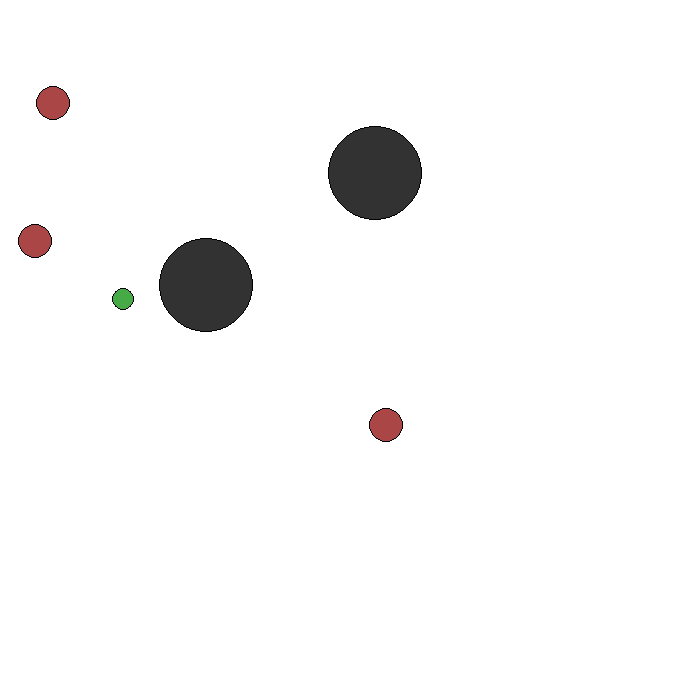

In [16]:
# Env with rendering
eval_env = simple_tag_v3.parallel_env(
    num_good=1,
    num_adversaries=3,
    num_obstacles=2,
    max_cycles=100,
    continuous_actions=True,
    render_mode="rgb_array",
    dynamic_rescaling=True,
)

obs, info = eval_env.reset()
frames = []

# Capture frames
while eval_env.agents:
    # Visual frame
    frames.append(eval_env.render())

    # Get actions
    action, _ = agent.get_action(obs)

    # Squeeze
    env_action = {a: act[0] for a, act in action.items()}

    # Step
    obs, reward, term, trunc, info = eval_env.step(env_action)

eval_env.close()

# Save gif
gif_path = os.path.join(dir_path, f"matd3_simple_tag_{run_name}.gif")
imageio.mimsave(gif_path, frames, fps=15)
print("GIF saved! Displaying below:")

# Display
Image(open(gif_path, 'rb').read())